In [1]:
import pandas as pd
from  trading_agent_class import Trading_Agent
from plot_vrp import plot_vrp

In [2]:
vix_options = pd.read_csv("data/vix_options.csv",parse_dates=["as_of_date", "expiration_date"],)
vix_data = pd.read_csv("data/vix_data.csv", parse_dates=["Date"])
vvix_data = pd.read_csv("data/vvix_data.csv", parse_dates=["Date"])
spx_data = pd.read_csv("data/spx_data.csv", parse_dates=["Date"])

feed_start = "2024-01-01"
start_date = "2024-06-01"
end_date = "2026-05-01"

date_list = vix_data["Date"].unique()

In [ ]:
agent = Trading_Agent(name="rv22", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 0.9, VRP_lt_threshold = 0.6, VRP_garch_threshold = 0.8, vvix_vix_threshold=0.5)


for today in date_list:
    vix = vix_data[vix_data["Date"] == today]["Close"].item()
    vvix = vvix_data[vvix_data["Date"] == today]["Close"].item()
    spx = spx_data[spx_data["Date"] == today]["Close"].item()
    rv22 = spx_data[spx_data["Date"] == today]["RV22"].item()
    option_chain = vix_options[vix_options["as_of_date"] == today]

    agent.feed_data(vix,vvix,spx,rv22)
    if not option_chain.empty:
        trading_signal = agent.signal()
        agent.trade(option_chain, trading_signal)
        agent.calculate_pnl(option_chain, today, vix)



Performance Metrics for rv22:
  Sharpe Ratio: -0.4348
  Sortino Ratio: -0.4618
  Annual Return: -0.18%
  Annual Volatility: 0.41%
  Max Drawdown: -0.98%


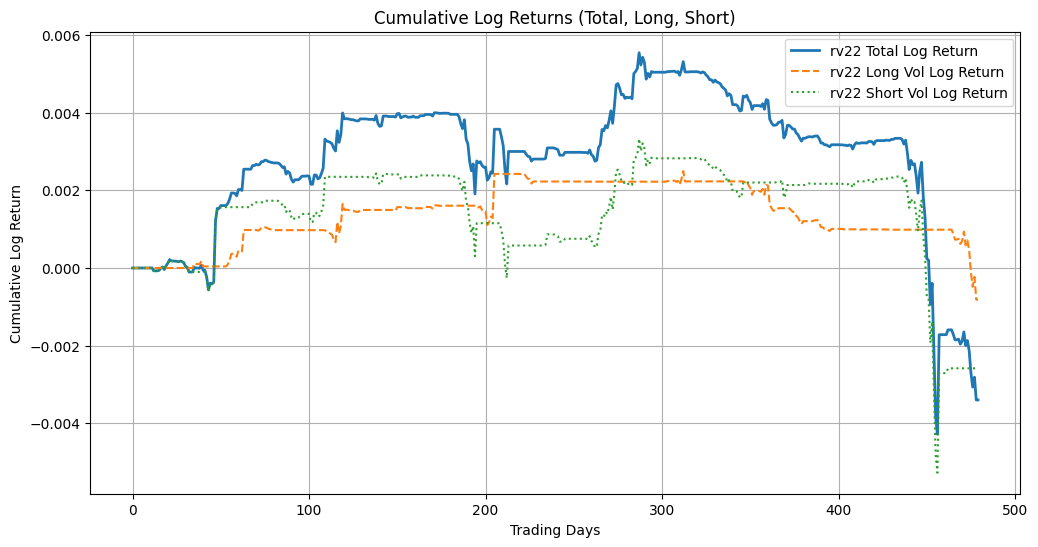

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
log_ret_total, log_ret_long, log_ret_short = agent.get_log_returns(initial_capital=10000.0)

plt.plot(log_ret_total, label=f"{agent.name} Total Log Return", linewidth=2)
plt.plot(log_ret_long, label=f"{agent.name} Long Vol Log Return", linestyle='--')
plt.plot(log_ret_short, label=f"{agent.name} Short Vol Log Return", linestyle=':')

# Print performance metrics
metrics = agent.get_performance_metrics(initial_capital=10000.0)
print(f"\nPerformance Metrics for {agent.name}:")
for k, v in metrics.items():
    if k in ["Annual Return", "Annual Volatility", "Max Drawdown"]:
        print(f"  {k}: {v:.2%}")
    else:
        print(f"  {k}: {v:.4f}")

plt.title("Cumulative Log Returns (Total, Long, Short)")
plt.xlabel("Trading Days")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()


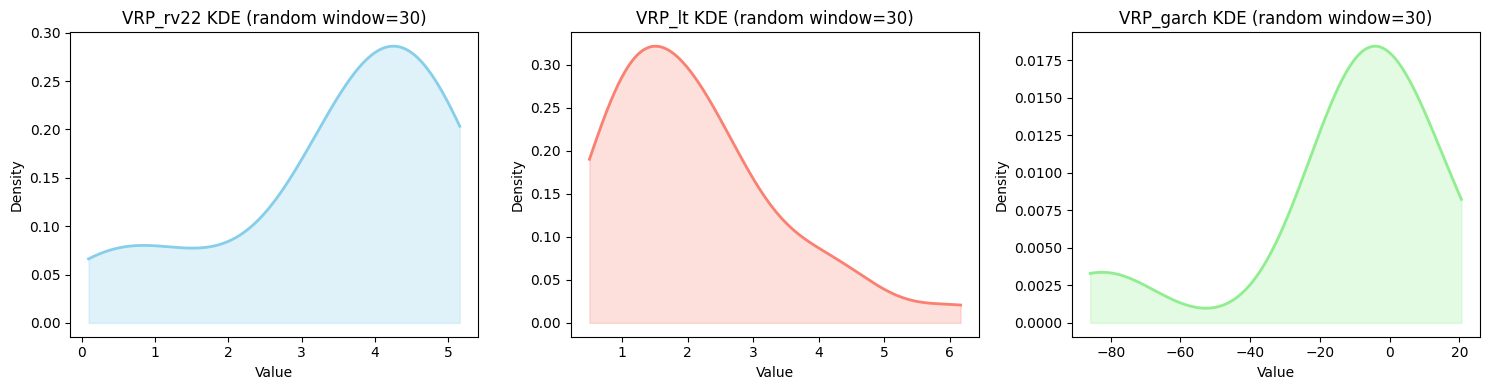

In [5]:
plot_vrp(agent)